# Customer Segmentation & Customer Value Analysis
### RFM Segmentation and Revenue-Based Customer Value on the Online Retail II Dataset

**Business question:** Which customer segments are most valuable, and where should retention efforts be prioritized?

**Approach:** Clean transaction data → calculate RFM metrics → assign behavioral segments → analyze historical revenue and annualized revenue run-rate → translate findings into retention priorities.

**Dataset:** Online Retail II — transaction data from a UK-based online retailer covering December 2009 to December 2011.

**Note:** Monetary values are reported in **GBP (£)**, consistent with the source dataset. The customer value section is descriptive and does not constitute a predictive CLV model.


## 1. Data Loading & Cleaning

Prepare a customer-level transaction dataset for RFM and value analysis. The cleaning decisions below are made explicitly because cancellations, missing customer identifiers, and invalid transaction values can distort customer-level metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [2]:
import os
os.makedirs("data", exist_ok=True)
df1 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df1, df2], ignore_index=True)


In [3]:
df = df.rename(columns={
    'Customer ID': 'CustomerID',
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice'
})


In [4]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['InvoiceDate'].min():%d %b %Y} to {df['InvoiceDate'].max():%d %b %Y}")


Rows: 1,067,371
Columns: 8
Date range: 01 Dec 2009 to 09 Dec 2011


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [6]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     243007
Country             0
dtype: int64

In [7]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [8]:
# Inspect the first few rows to confirm the schema and transaction structure.
df.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [9]:
# Inspect the most extreme quantity to determine whether it is a genuine transaction or a cancellation.
df[df['Quantity'].abs() == 80995]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


In [10]:
# Negative prices are invalid for completed sales and are investigated before filtering.
df[df['UnitPrice'] < 0]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


### Missing customer identifiers

Transactions without a CustomerID cannot be attributed to an individual customer, so they are excluded from customer-level segmentation.

In [11]:
missing_pct = df['CustomerID'].isnull().mean() * 100
print(f"{missing_pct:.1f}% of rows have no CustomerID")

df = df.dropna(subset=['CustomerID'])


22.8% of rows have no CustomerID


In [12]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)


In [13]:
cancelled = df[df['InvoiceNo'].str.startswith('C')]
cancelled_pct = len(cancelled) / len(df) * 100
print(f"{cancelled_pct:.2f}% of remaining transactions are cancellations")

df = df[~df['InvoiceNo'].str.startswith('C')]


2.27% of remaining transactions are cancellations


In [14]:
# Confirm that cancellation records are negative-quantity transactions.
(cancelled['Quantity'] < 0).mean() * 100


np.float64(100.0)

### Cancellations

Cancellation records represent returns/order corrections rather than completed purchases, so they are excluded from revenue and RFM calculations. The cancellation rate is retained as a useful operational signal rather than being silently discarded.

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

dupe_count = df.duplicated().sum()
print(f"{dupe_count:,} duplicate rows found ({dupe_count / len(df) * 100:.2f}%)")

df = df.drop_duplicates()


26,125 duplicate rows found (3.24%)


In [16]:
print(f"Rows with non-positive UnitPrice: {(df['UnitPrice'] <= 0).sum():,}")
print(f"Rows with non-positive Quantity: {(df['Quantity'] <= 0).sum():,}")


Rows with non-positive UnitPrice: 70
Rows with non-positive Quantity: 0


In [17]:
df = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)]


In [18]:
df.to_pickle('data/cleaned_online_retail.pkl')


In [19]:
# Reload the cleaned dataset so the downstream analysis can be run independently from the raw-data cleaning step.
df = pd.read_pickle('data/cleaned_online_retail.pkl')


## 2. RFM Feature Engineering

Calculate Recency, Frequency, and Monetary value at customer level. Each metric is converted into a 1–5 score, where higher scores represent stronger customer behavior.

### 2.1 Calculate Recency, Frequency, and Monetary Value


In [20]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Snapshot date = one day after the final transaction in the dataset.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [21]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Total'] = rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)


### 2.2 Scoring Customers (1–5 scale per dimension)


In [22]:
def segment_customer(row):
    r = row['R_score']
    f = row['F_score']
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f == 3:
        return 'Needs Attention'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

### 2.3 Assigning Customers to Behavioral Segments


In [23]:
rfm['Segment'].value_counts()

Segment
Lost                   1523
Champions              1482
Loyal Customers        1221
Needs Attention         471
New Customers           443
Potential Loyalists     385
At Risk                 353
Name: count, dtype: int64

## 3. Segmentation Visuals

Compare segment size, revenue contribution, and customer behavior to understand where value is concentrated and how the segments differ.

### 3.1 Customer Count by Segment


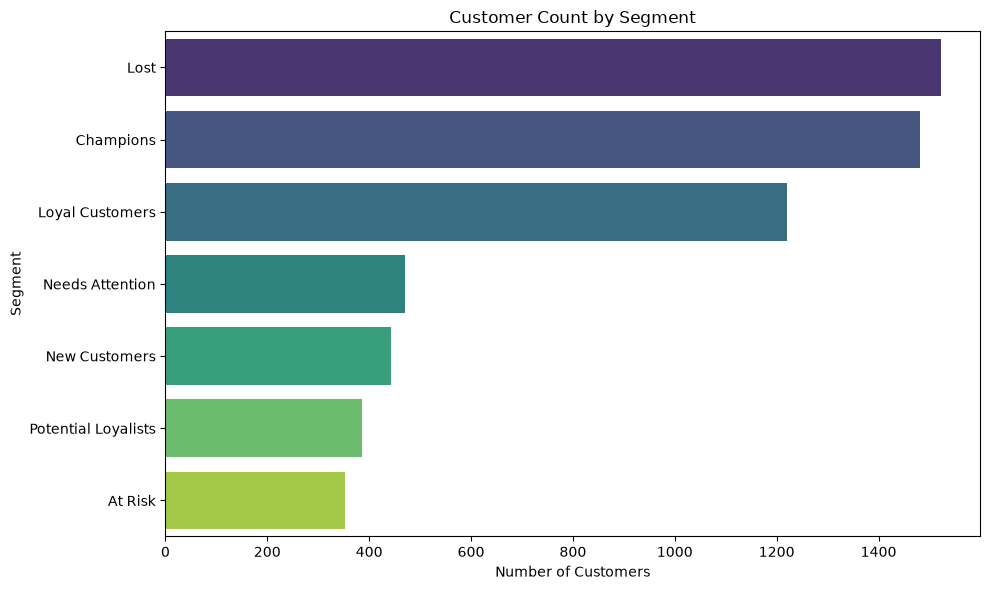

In [24]:
plt.figure(figsize=(10, 6))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index,
            hue=segment_counts.index, legend=False, palette='viridis')
plt.title('Customer Count by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()


### 3.2 Revenue Contribution by Segment

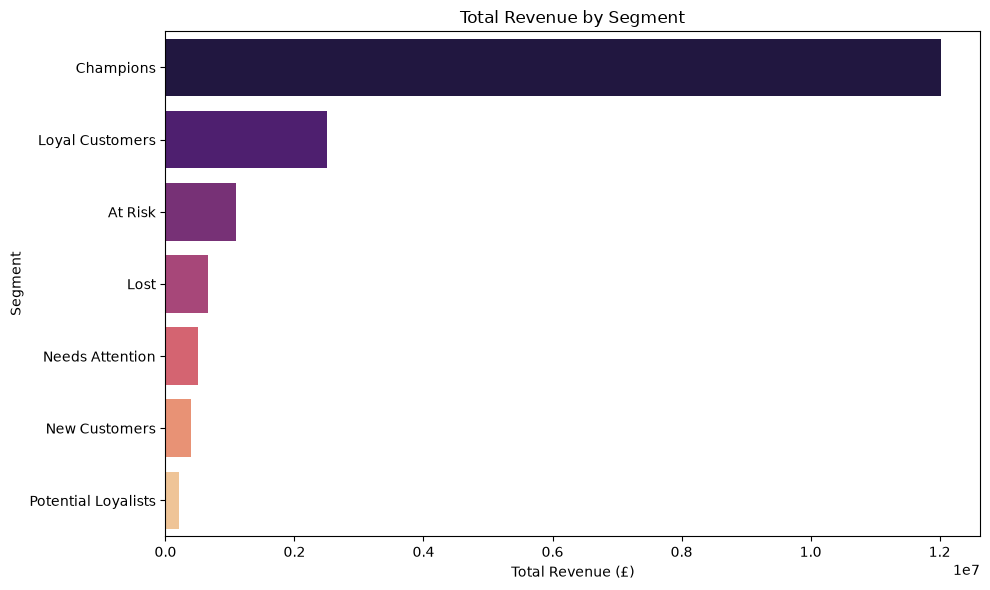

In [25]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_revenue.values, y=segment_revenue.index,
            hue=segment_revenue.index, legend=False, palette='magma')
plt.title('Total Revenue by Segment')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()


In [26]:
total_revenue = rfm['Monetary'].sum()
segment_pct = (segment_revenue / total_revenue * 100).round(1)
print(segment_pct)


Segment
Champions              69.2
Loyal Customers        14.4
At Risk                 6.3
Lost                    3.8
Needs Attention         2.9
New Customers           2.3
Potential Loyalists     1.2
Name: Monetary, dtype: float64


### 3.3 Recency vs. Frequency by Segment

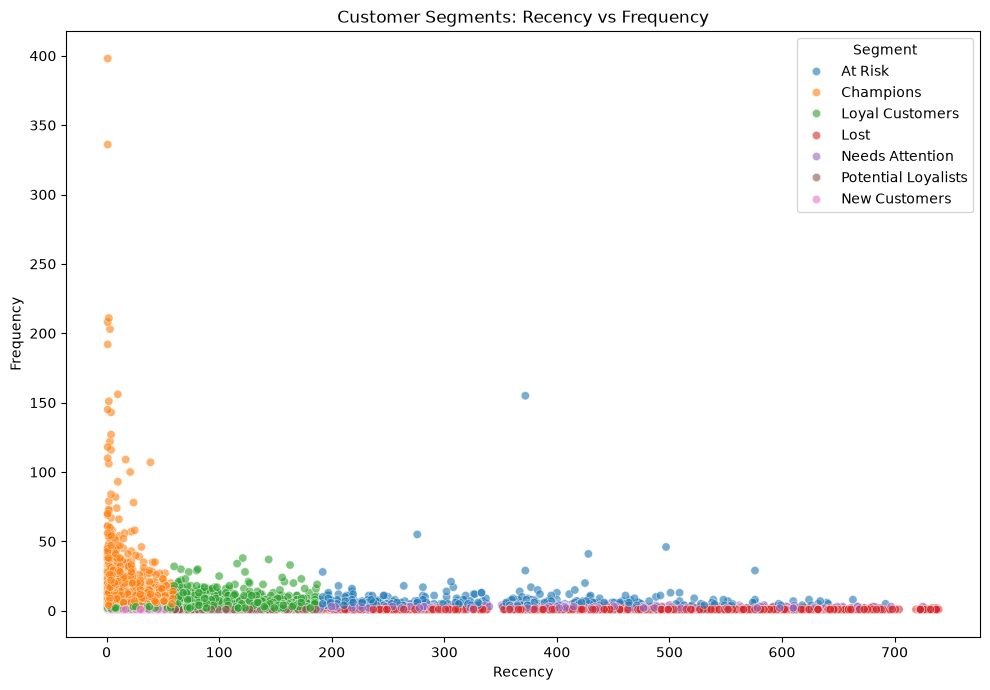

In [27]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Segment', palette='tab10', alpha=0.6)
plt.title('Customer Segments: Recency vs Frequency')
plt.tight_layout()
plt.show()

### 3.4 Recency vs. Monetary by Segment (Log Scale)

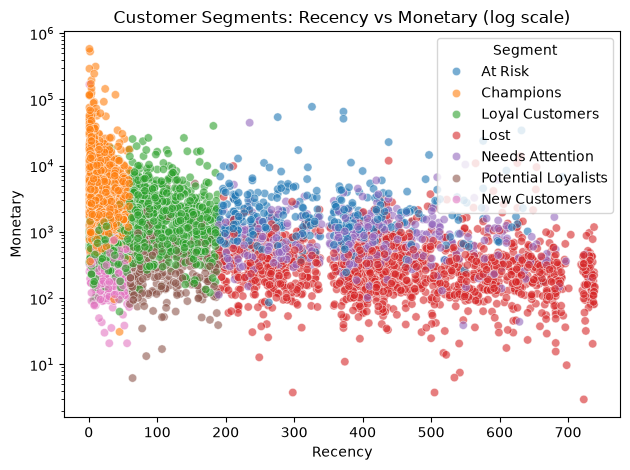

In [28]:
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Segment', palette='tab10', alpha=0.6)
plt.yscale('log')  # Monetary is usually heavily skewed; log scale makes patterns visible
plt.title('Customer Segments: Recency vs Monetary (log scale)')
plt.tight_layout()
plt.show()

## 4. Customer Value Analysis

This section measures customer value using **historical revenue** and an **annualized revenue run-rate**. The annualized metric answers: *if a customer's observed purchasing rate continued for the next 12 months, what revenue would that imply?*

This is a descriptive/annualized revenue measure, **not a predictive CLV model**.

### 4.1 Average Order Value & Customer Lifespan


In [29]:
customer_value = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

customer_value.columns = ['CustomerID', 'Frequency', 'TotalRevenue']
customer_value['AvgOrderValue'] = customer_value['TotalRevenue'] / customer_value['Frequency']


In [30]:
lifespan = df.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max']).reset_index()
lifespan['Lifespan_Days'] = (lifespan['max'] - lifespan['min']).dt.days
lifespan['Lifespan_Months'] = lifespan['Lifespan_Days'] / 30

customer_value = customer_value.merge(
    lifespan[['CustomerID', 'Lifespan_Months']],
    on='CustomerID'
)


### 4.2 Historical Revenue & Annualized Revenue Run-Rate


In [31]:
# One-time buyers have a zero observed lifespan, so use the average positive lifespan
# only when calculating a monthly purchase-rate estimate.
avg_lifespan = customer_value.loc[
    customer_value['Lifespan_Months'] > 0, 'Lifespan_Months'
].mean()

customer_value['Lifespan_Months_Adj'] = customer_value['Lifespan_Months'].replace(0, avg_lifespan)
customer_value['PurchaseFreq_Monthly'] = customer_value['Frequency'] / customer_value['Lifespan_Months_Adj']

# Annualized revenue run-rate: implied revenue over 12 months at the observed monthly rate.
customer_value['Monthly_Revenue_Rate'] = (
    customer_value['AvgOrderValue'] * customer_value['PurchaseFreq_Monthly']
)
customer_value['Annualized_Revenue_RunRate'] = customer_value['Monthly_Revenue_Rate'] * 12


In [32]:
# Sanity check: historical revenue should equal average order value × order frequency.
customer_value['Revenue_Check'] = (
    customer_value['AvgOrderValue'] * customer_value['Frequency']
)
print(f"Maximum absolute revenue difference: {(customer_value['TotalRevenue'] - customer_value['Revenue_Check']).abs().max():.10f}")


Maximum absolute revenue difference: 0.0000000000


### 4.3 Merging Customer Value Metrics into the Main Segmentation Table


In [33]:
rfm = rfm.merge(
    customer_value[['CustomerID', 'TotalRevenue', 'Annualized_Revenue_RunRate']],
    on='CustomerID'
)


### 4.4 Average Annualized Revenue Run-Rate by Segment


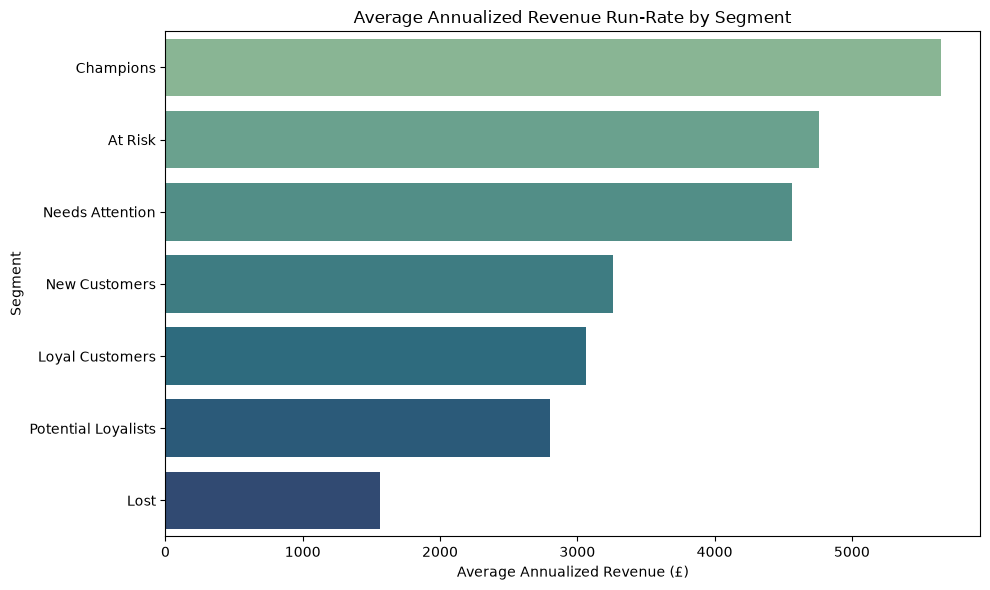

In [34]:
segment_run_rate = rfm.groupby('Segment')['Annualized_Revenue_RunRate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_run_rate.values, y=segment_run_rate.index,
            hue=segment_run_rate.index, legend=False, palette='crest')
plt.title('Average Annualized Revenue Run-Rate by Segment')
plt.xlabel('Average Annualized Revenue (£)')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()


In [35]:
segment_summary = pd.DataFrame({
    'Customer_Count': rfm['Segment'].value_counts(),
    'Total_Revenue': segment_revenue,
    'Revenue_Pct': segment_pct,
    'Avg_Annualized_Revenue': rfm.groupby('Segment')['Annualized_Revenue_RunRate'].mean().round(2)
}).sort_values('Total_Revenue', ascending=False)

print(segment_summary)


                     Customer_Count  Total_Revenue  Revenue_Pct  Avg_Annualized_Revenue
Segment                                                                                
Champions                      1482   1.202433e+07         69.2                 5650.62
Loyal Customers                1221   2.510046e+06         14.4                 3061.24
At Risk                         353   1.090694e+06          6.3                 4762.54
Lost                           1523   6.544267e+05          3.8                 1565.05
Needs Attention                 471   4.986900e+05          2.9                 4561.77
New Customers                   443   3.922670e+05          2.3                 3261.80
Potential Loyalists             385   2.043497e+05          1.2                 2804.70


## 5. Key Findings

### 1. Champions are a small but highly valuable customer group
Champions account for about **25% of customers but approximately 69% of revenue**, showing strong concentration of business value in a relatively small segment.

**Implication:** Champions should be protected through loyalty initiatives, personalized engagement, and cross-sell/upsell opportunities.

### 2. Customer count alone does not indicate business value
Lost customers are one of the largest segments by customer count, but they contribute only about **4% of total revenue**. Champions have a similar-sized customer base but contribute far more revenue.

**Implication:** retention resources should be allocated using customer value and behavior rather than segment size alone.

### 3. At Risk customers are the highest-priority retention target, not Lost

This is the central insight of the analysis. At Risk customers have an average annualized revenue run-rate of **£4,762.54**, about 84% of Champions' **£5,650.62**, and more than 3× Lost's **£1,565.05**. This indicates that At Risk customers had substantially higher historical purchasing value before becoming inactive.

Because this segment is also relatively small (353 customers, about 6% of the base), a targeted win-back campaign can focus resources on customers with stronger historical value rather than applying the same intervention to the much larger Lost segment.

**Recommendation:** prioritize retention/win-back spend on **At Risk** over **Lost**. Lost customers can be addressed through lower-cost, low-touch re-engagement, while At Risk customers justify more personalized outreach given their stronger historical revenue rate.

**Important limitation:** the annualized revenue run-rate assumes the observed purchase rate continues for the next 12 months. It does not model future churn, retention probability, discounting, or margin, so it should not be interpreted as predictive CLV.


## 6. Conclusion & Next Steps

This analysis combines RFM segmentation with customer value analysis to prioritize retention effort. The headline result is that Champions represent about 25% of customers but generate about 69% of revenue, while At Risk customers show a substantially higher historical revenue run-rate than Lost customers.

The key practical recommendation is to prioritize targeted win-back activity for **At Risk customers** over broad investment in the much larger Lost segment. Lost customers can still be addressed through lower-cost, low-touch re-engagement.

**Limitations:** the annualized revenue run-rate is a descriptive projection based on observed purchasing behavior. It does not predict whether customers will remain active, and it does not account for profit margin or discounting.

**Potential extensions:**
- Build a predictive CLV model such as BG/NBD + Gamma-Gamma.
- Build cohort retention curves to understand how churn risk changes over customer tenure.
- Test the At-Risk-over-Lost prioritization with an A/B win-back campaign.
- Segment by product category or country to test whether the same patterns hold across customer subgroups.
